# **Implementing Linear Regression using NumPy**

In [129]:
import numpy as np
import matplotlib.pyplot as plt

In [130]:
X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])

In [131]:
def model(X, w, b):
    return w * X + b

In [132]:
def plot(model=None, w=0, b=0):
    plt.xlabel("x")
    plt.ylabel("y")
    
    if model:
        plt.plot(X, model(X, w, b), linestyle=":")
           
    plt.grid()
    plt.scatter(X, y)

In [133]:
def mse(y, y_pred):
    return np.mean((y - y_pred)**2)

In [134]:
def gradients(X, y, w, b):
    n = len(X)
    y_pred = w * X + b

    dw = ((2/n) * np.sum((y_pred - y) * X))
    db = ((2/n * np.sum(y_pred - y)))
    return dw, db

In [135]:
w = 0
b = 0

dw, db = gradients(X, y, w, b)

print(dw)
print(db)

-50.0
-14.0


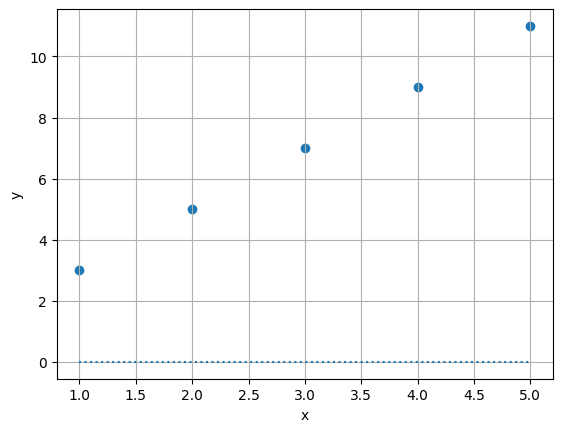

In [136]:
plot(model)

In [154]:
def train(X, y, learning_rate=0.01, iterations=1000):
    w = 0
    b = 0
    history = [(w,b)]
    for _ in range(iterations):
        dw, db = gradients(X, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db
        history.append((w,b))

    return w, b, lambda x: w * x + b, history

In [155]:
w, b, trained_model, history = train(X, y)

In [156]:
trained_model(6)

np.float64(13.009273360495946)

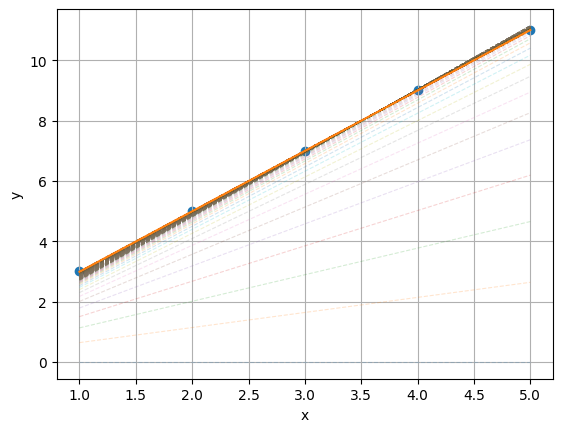

In [166]:
plot()
for candidate_w, candidate_b in history:
    l = lambda x: candidate_w * x + candidate_b
    plt.plot(X, l(X), linestyle="--", alpha=0.2, linewidth=0.8)

plt.plot(X, trained_model(X))
plt.grid(True)